In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [5]:
dataset1 = pd.read_csv('/content/drive/MyDrive/Deep_learning/Dataset_DL.csv')
X = dataset1[['Input']].values
y = dataset1[['Output']].values

In [6]:
dataset1.head(10)

,Input,Output
0,1,2
1,2,4
2,8,16
3,32,64
4,35,65
5,40,68
6,62,74
7,78,82
8,86,94


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [8]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [10]:
# Name: YUVARAJ V
# # Register Number: 212223230252
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1,8)
        self.fc2 = nn.Linear(8,10)
        self.fc3 = nn.Linear(10,1)
        self.relu = nn.ReLU()
        self.history = {'loss': []}
  def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [11]:
# Initialize the Model, Loss Function, and Optimizer
lig = NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.RMSprop(lig.parameters(), lr=0.001)

In [12]:
# Name: YUVARAJ V
# # Register Number: 212223230252
def train_model(lig, X_train, y_train, criterion, optimizer, epochs=2000):
  for epoch in range(epochs):
        optimizer.zero_grad()
        loss = criterion(lig(X_train), y_train)
        loss.backward()
        optimizer.step()
        lig.history['loss'].append(loss.item())
        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')

In [13]:
train_model(lig, X_train_tensor, y_train_tensor, criterion, optimizer)

Epoch [0/2000], Loss: 2617.761963
Epoch [200/2000], Loss: 2350.251709
Epoch [400/2000], Loss: 1860.479370
Epoch [600/2000], Loss: 1256.709229
Epoch [800/2000], Loss: 743.250061
Epoch [1000/2000], Loss: 500.686035
Epoch [1200/2000], Loss: 397.496735
Epoch [1400/2000], Loss: 289.458038
Epoch [1600/2000], Loss: 202.799149
Epoch [1800/2000], Loss: 151.089569


In [14]:
with torch.no_grad():
    test_loss = criterion(lig(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')

Test Loss: 159.641525


In [15]:
loss_df = pd.DataFrame(lig.history)

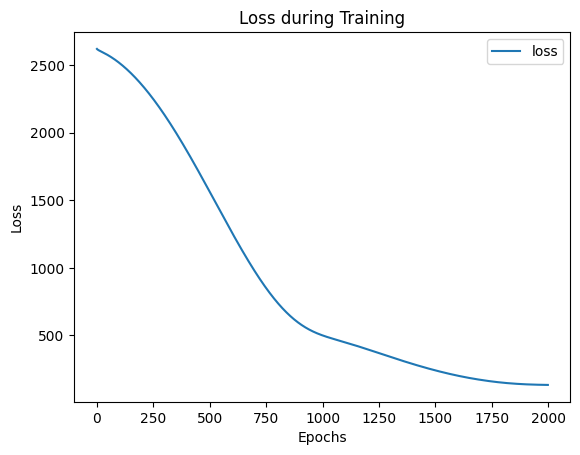

In [16]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [17]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = lig(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 19.791852951049805
